In [4]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_excel(list(uploaded.keys())[0])  # use pd.read_csv() if your file is a .csv
df.head()

Saving online_retail_II.csv to online_retail_II.csv


ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [5]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv(list(uploaded.keys())[0], encoding='latin1')
df.head()

Saving online_retail_II.csv to online_retail_II (1).csv


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Shape: (1067371, 8)

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


In [7]:
# Drop rows without a Customer ID — can't segment customers we can't identify
df = df.dropna(subset=['Customer ID'])

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check for negative Quantity (returns/cancellations) and negative Price
print("Negative Quantity rows:", (df['Quantity'] < 0).sum())
print("Negative Price rows:", (df['Price'] < 0).sum())
print("\nNew shape after dropping missing Customer IDs:", df.shape)

Negative Quantity rows: 18744
Negative Price rows: 0

New shape after dropping missing Customer IDs: (824364, 8)


In [8]:
# Remove returns/cancellations (negative quantities)
df = df[df['Quantity'] > 0]

# Create a Total Sales column (Quantity x Price) — this is what "Monetary" in RFM will be based on
df['TotalSales'] = df['Quantity'] * df['Price']

print("Shape after removing returns:", df.shape)
print("\nDate range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
df.head()

Shape after removing returns: (805620, 9)

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [9]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                       # Frequency
    'TotalSales': 'sum'                                         # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
print("Number of unique customers:", rfm.shape[0])
rfm.describe()

Number of unique customers: 5881


,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,3017.076888
std,209.474135,13.012879,14734.128619
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,347.800000
50%,96.000000,3.000000,897.620000
75%,380.000000,7.000000,2304.180000
max,739.000000,398.000000,608821.650000


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,5.881000e+03,5.881000e+03,5.881000e+03
mean,-4.953622e-17,-2.778861e-17,2.416401e-18
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.570384e-01,-4.063394e-01,-2.047853e-01
25%,-8.376818e-01,-4.063394e-01,-1.811783e-01
50%,-5.034832e-01,-2.526325e-01,-1.438590e-01
75%,8.524080e-01,5.478146e-02,-4.838817e-02
max,2.566369e+00,3.010449e+01,4.111923e+01


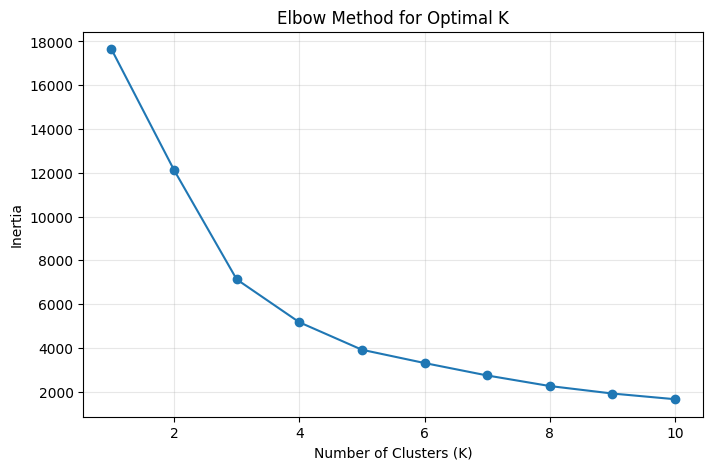

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(alpha=0.3)
plt.show()

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm['Cluster'].value_counts())
rfm.groupby('Cluster').mean()

Cluster
0    3842
1    2000
2      35
3       4
Name: count, dtype: int64


,Recency,Frequency,Monetary
Cluster,,,
0,66.991931,7.306351,3008.619160
1,463.234000,2.211000,764.479201
2,25.942857,103.742857,83086.079771
3,3.500000,212.750000,436835.792500


**Cluster Interpretation:**
- **Cluster 0 (n=3,842) — Regular Customers:** Moderate recency (~67 days), consistent order frequency (~7), average spend (~₹3,000). The core customer base.
- **Cluster 1 (n=2,000) — Lapsed/One-Time Buyers:** High recency (~463 days = over a year since last purchase), low frequency and spend. Likely churned customers.
- **Cluster 2 (n=35) — High-Value Loyal Customers:** Very recent activity, high frequency (~104 orders), high spend (~₹83K). Prime targets for retention/loyalty programs.
- **Cluster 3 (n=4) — Extreme Outliers:** Recency near 0, frequency over 200 orders, spend near ₹437K. This pattern strongly suggests these are wholesale/reseller accounts rather than typical retail customers, not organic consumer behavior.

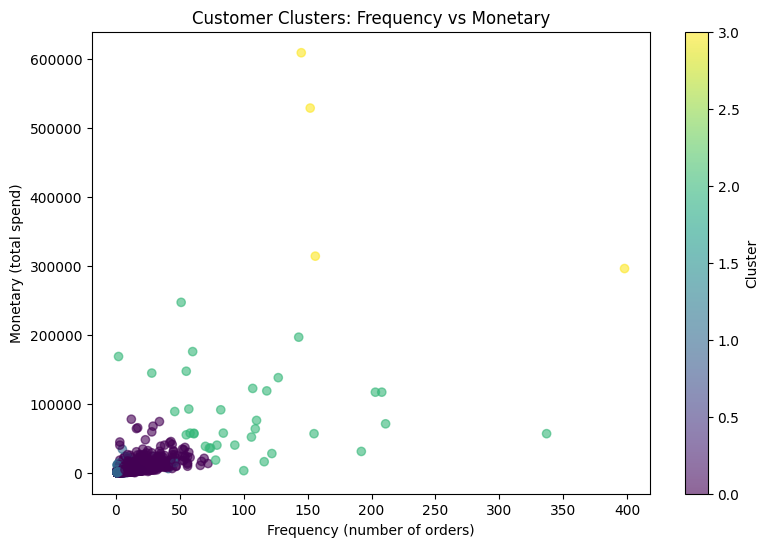

In [13]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Frequency (number of orders)')
plt.ylabel('Monetary (total spend)')
plt.title('Customer Clusters: Frequency vs Monetary')
plt.colorbar(scatter, label='Cluster')
plt.show()

**Observation:** The scatter plot shows extreme skew — the vast majority of customers (Clusters 0 and 1) cluster tightly near the origin, while a small number of high-value outliers (Clusters 2 and 3) stretch the axes dramatically. This confirms the "80/20" pattern common in retail: a small fraction of customers drive a disproportionate share of revenue.

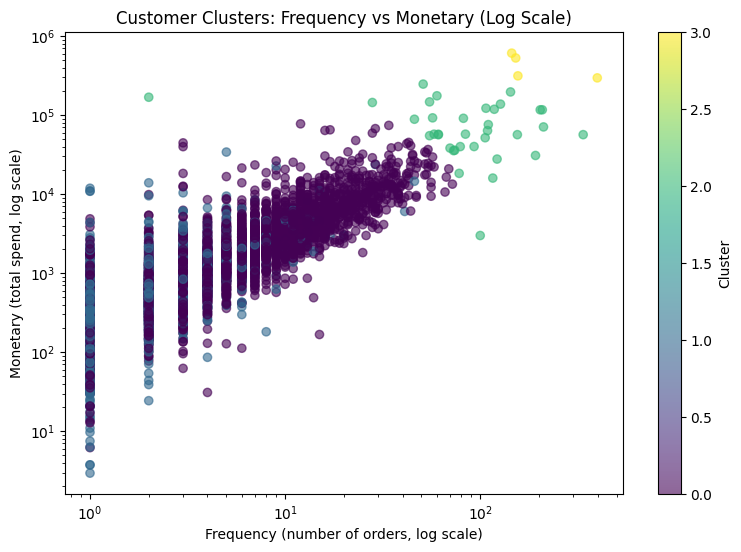

In [14]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Frequency (number of orders, log scale)')
plt.ylabel('Monetary (total spend, log scale)')
plt.title('Customer Clusters: Frequency vs Monetary (Log Scale)')
plt.xscale('log')
plt.yscale('log')
plt.colorbar(scatter, label='Cluster')
plt.show()

**Observation:** The log-scale view reveals clear cluster separation that the linear plot obscured. There's a visible progression from low-frequency/low-spend customers (Cluster 1, blue) through mid-tier regulars (Cluster 0, purple) to high-value loyal customers and outliers (Clusters 2 and 3, green/yellow). This confirms the clustering captured a genuine behavioral spectrum rather than arbitrary groupings.

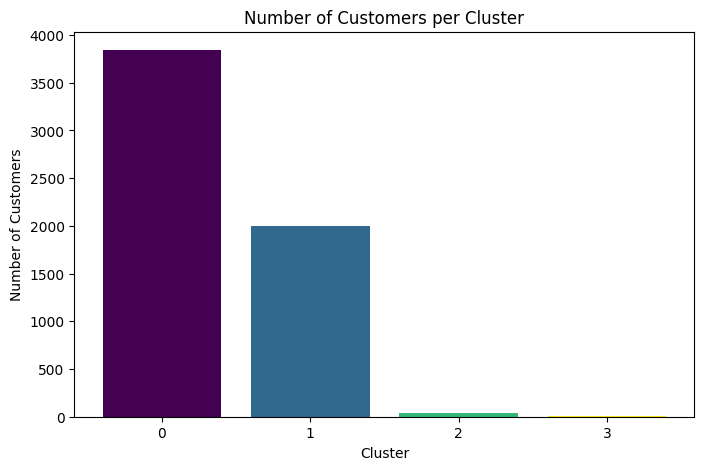

In [15]:
plt.figure(figsize=(8, 5))
cluster_counts = rfm['Cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color=['#440154', '#31688e', '#35b779', '#fde725'])
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.show()

**Observation:** Cluster sizes are heavily imbalanced — Cluster 0 (Regular Customers) and Cluster 1 (Lapsed Buyers) together make up over 99% of the customer base (5,842 of 5,881), while Clusters 2 and 3 combined represent just 39 customers. Despite their tiny size, Clusters 2 and 3 generate disproportionately high revenue per customer, reinforcing the earlier finding that a small group of customers drives outsized value.


## Insights & Recommended Marketing Actions

1. **Cluster 2 & 3 — High-Value/Wholesale Customers (n=39):** Despite being <1% of customers,
   they likely account for a disproportionate share of total revenue. Recommend a dedicated
   account manager or loyalty program to protect this relationship, and investigate whether
   Cluster 3 represents wholesale/B2B accounts warranting a separate pricing or service model.

2. **Cluster 0 — Regular Customers (n=3,842):** The core, healthy customer base. Recommend
   standard retention campaigns (email newsletters, seasonal promotions) to nudge them toward
   higher frequency, potentially moving them into Cluster 2 over time.

3. **Cluster 1 — Lapsed Customers (n=2,000):** Haven't purchased in over a year on average.
   Recommend a win-back campaign — targeted discount codes or "we miss you" emails — since
   this group represents significant dormant revenue potential if even a fraction re-engage.